In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [5]:
# прочитаем наши данные из файла data и запишем в переменную
df = pd.read_csv('C:/Users/majkl/WorkSpace/dirty_data_analysis/data.csv')
# выведем инофрмацию о датафрейме
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   int64  
 1   customer_id       941 non-null    float64
 2   order_date        790 non-null    object 
 3   revenue           966 non-null    float64
 4   product_category  966 non-null    object 
 5   country           939 non-null    object 
 6   email             796 non-null    object 
 7   age               956 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 62.6+ KB


,order_id,customer_id,order_date,revenue,product_category,country,email,age
0,1,271.0,8.5.2023,262.53,elecronics,United States,NaN,55.0
1,2,NaN,неизвестно,140.94,beauty,America,user976@,20.0
2,3,135.0,NaN,177.72,cloting,RUSSIA,invalid_email,64.0
3,4,81.0,неизвестно,78.22,elecronics,Germany,invalid_email,25.0
4,5,252.0,2023-08-21,119.89,Книги,US,user157@gmail.com,18.0


In [6]:
# Проверяем пропуски
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent.round(2)
})
print(missing_info)

                  Пропусков  Процент
order_id                  0      0.0
customer_id              59      5.9
order_date              210     21.0
revenue                  34      3.4
product_category         34      3.4
country                  61      6.1
email                   204     20.4
age                      44      4.4


In [7]:
# Проверяем дубликаты
duplicates = df.duplicated().sum()
print(f"\n🔁 ДУБЛИКАТЫ: {duplicates} строк")


🔁 ДУБЛИКАТЫ: 0 строк


In [8]:
# Анализируем выбросы в выручке
print(f"\n📈 ВЫБРОСЫ В ВЫРУЧКЕ:")
print(f"• Минимальная выручка: ${df['revenue'].min():.2f}")
print(f"• Максимальная выручка: ${df['revenue'].max():.2f}")
print(f"• Медиана: ${df['revenue'].median():.2f}")


📈 ВЫБРОСЫ В ВЫРУЧКЕ:
• Минимальная выручка: $-91.29
• Максимальная выручка: $4997.84
• Медиана: $155.11


In [9]:
# Анализируем проблемы в категориях
print(f"\n🏷️  ПРОБЛЕМЫ В КАТЕГОРИЯХ:")
unique_categories = df['product_category'].nunique()
print(f"• Уникальных 'категорий': {unique_categories}")
print("• Примеры категорий:", df['product_category'].unique()[:10])


🏷️  ПРОБЛЕМЫ В КАТЕГОРИЯХ:
• Уникальных 'категорий': 19
• Примеры категорий: ['elecronics' 'beauty' 'cloting' 'Книги' 'bokks' 'BOOKS' 'clothing'
 'ELECTRONICS' 'Красота' 'BEAUTY ']


### ОЧИСТКА ДАННЫХ

In [10]:
df_clean = df.copy()

In [11]:
# Сохраняем исходное количество строк
original_rows = len(df_clean)

In [ ]:
# Дубликаты ене обнаружены
# df_clean = df_clean.drop_duplicates()
# print(f"✅ Удалено дубликатов: {original_rows - len(df_clean)}")

In [ ]:
# Исправляем категории товаров
category_mapping = {
    'ELECTRONICS': 'Электроника', 'electronics': 'Электроника', 
    'elecronics': 'Электроника', 'Eletronics': 'Электроника',
    'CLOTHING': 'Одежда', 'clothing': 'Одежда', 'cloting': 'Одежда',
    'BOOKS': 'Книги', 'books': 'Книги', 'bokks': 'Книги', 'BOOK': 'Книги',
    'BEAUTY': 'Красота', 'beauty': 'Красота', 'beuty': 'Красота', 'BEAUTY ': 'Красота'
}

# Заполняем пропуски в категориях модой
most_common_category = df_clean['product_category_clean'].mode()[0]
df_clean['product_category_clean'] = df_clean['product_category_clean'].fillna(most_common_category)

print(f"✅ Категории стандартизированы. Было {unique_categories}, стало {df_clean['product_category_clean'].nunique()}")

✅ Категории стандартизированы. Было 19, стало 4


In [ ]:
# Исправляем страны


country_mapping = {
    'Russia': 'Россия', 'RUSSIA': 'Россия', 'russia': 'Россия', 'RU': 'Россия', 
    'Russian Federation': 'Россия',
    'USA': 'США', 'United States': 'США', 'US': 'США', 'America': 'США',
    'Germany': 'Германия', 'GERMANY': 'Германия', 'germany': 'Германия', 'DE': 'Германия'
}

df_clean['country_clean'] = df_clean['country'].map(country_mapping)
df_clean['country_clean'] = df_clean['country_clean'].fillna('Неизвестно')

print(f"✅ Страны стандартизированы. Было {df['country'].nunique()}, стало {df_clean['country_clean'].nunique()}")

✅ Страны стандартизированы. Было 16, стало 4


In [ ]:
# Исправляем даты

def parse_date(date_str):
    if pd.isna(date_str) or date_str == 'неизвестно':
        return None
    
    try:
        # Пробуем разные форматы
        if isinstance(date_str, str):
            if '-' in date_str and len(date_str) == 10:  # YYYY-MM-DD
                return pd.to_datetime(date_str)
            elif '/' in date_str:  # MM/DD/YYYY
                return pd.to_datetime(date_str, format='%m/%d/%Y')
            elif '.' in date_str:  # DD.MM.YYYY
                return pd.to_datetime(date_str, format='%d.%m.%Y')
    except:
        return None
    
    return None

df_clean['order_date_clean'] = df_clean['order_date'].apply(parse_date)

# Заполняем пропуски в датах случайными датами из существующих
valid_dates = df_clean['order_date_clean'].dropna()
if len(valid_dates) > 0:
    df_clean['order_date_clean'] = df_clean['order_date_clean'].apply(
        lambda x: np.random.choice(valid_dates) if pd.isna(x) else x
    )

print(f"✅ Даты исправлены. Валидных дат: {df_clean['order_date_clean'].notna().sum()}/{len(df_clean)}")

✅ Даты исправлены. Валидных дат: 1000/1000


In [ ]:
# Исправляем выручку

# Заменяем отрицательные значения на положительные (возвраты → 0 для упрощения)
df_clean['revenue_clean'] = df_clean['revenue'].apply(lambda x: 0 if x and x < 0 else x)

# Заполняем пропуски медианным значением
median_revenue = df_clean['revenue_clean'].median()
df_clean['revenue_clean'] = df_clean['revenue_clean'].fillna(median_revenue)

# Ограничиваем выбросы 95 перцентилем
revenue_95 = df_clean['revenue_clean'].quantile(0.95)
df_clean['revenue_clean'] = np.where(
    df_clean['revenue_clean'] > revenue_95, 
    revenue_95, 
    df_clean['revenue_clean']
)

print(f"✅ Выручка исправлена. Выбросы ограничены на уровне ${revenue_95:.2f}")


✅ Выручка исправлена. Выбросы ограничены на уровне $294.28


In [ ]:
# Исправляем возраст
print("\n👥 ИСПРАВЛЯЕМ ВОЗРАСТ...")

# Исправляем нереалистичные значения возраста
df_clean['age_clean'] = df_clean['age'].apply(
    lambda x: np.random.randint(25, 55) if (x is None or x < 18 or x > 100) else x
)

print(f"✅ Возраст исправлен. Диапазон: {df_clean['age_clean'].min()}-{df_clean['age_clean'].max()} лет")


👥 ИСПРАВЛЯЕМ ВОЗРАСТ...
✅ Возраст исправлен. Диапазон: 18.0-69.0 лет


In [ ]:
# Валидируем email
print("\n📧 ВАЛИДИРУЕМ EMAIL АДРЕСА...")

def is_valid_email(email):
    if pd.isna(email):
        return False
    pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern, str(email)))

df_clean['is_valid_email'] = df_clean['email'].apply(is_valid_email)
valid_emails = df_clean['is_valid_email'].sum()

print(f"✅ Валидных email: {valid_emails}/{len(df_clean)} ({valid_emails/len(df_clean)*100:.1f}%)")


📧 ВАЛИДИРУЕМ EMAIL АДРЕСА...
✅ Валидных email: 194/1000 (19.4%)


In [30]:
df_clean.head()

,order_id,customer_id,order_date,revenue,product_category,country,email,age,product_category_clean,country_clean,order_date_clean,was_date_missing,revenue_clean,age_clean,is_valid_email
0,1,271.0,8.5.2023,262.53,elecronics,United States,NaN,55.0,Электроника,США,2023-05-08,False,262.53,55.0,False
1,2,NaN,неизвестно,140.94,beauty,America,user976@,20.0,Красота,США,2023-10-21,False,140.94,20.0,False
2,3,135.0,NaN,177.72,cloting,RUSSIA,invalid_email,64.0,Одежда,Россия,2023-02-28,True,177.72,64.0,False
3,4,81.0,неизвестно,78.22,elecronics,Germany,invalid_email,25.0,Электроника,Германия,2023-10-22,False,78.22,25.0,False
4,5,252.0,2023-08-21,119.89,Книги,US,user157@gmail.com,18.0,Электроника,США,2023-08-21,False,119.89,18.0,True


In [35]:
df_clean.to_csv('dirty_data_cleaned.csv', index=False, encoding='utf-8')

### АНАЛИЗ ОЧИЩЕННЫХ ДАННЫХ

In [31]:
# Основные метрики
total_revenue = df_clean['revenue_clean'].sum()
avg_revenue = df_clean['revenue_clean'].mean()
total_orders = len(df_clean)

print(f"💰 ВЫРУЧКА: ${total_revenue:,.2f}")
print(f"📦 ЗАКАЗОВ: {total_orders}")
print(f"📊 СРЕДНИЙ ЧЕК: ${avg_revenue:.2f}")

💰 ВЫРУЧКА: $156,984.55
📦 ЗАКАЗОВ: 1000
📊 СРЕДНИЙ ЧЕК: $156.98


In [32]:
# Анализ по категориям
print("\n🏷️  ВЫРУЧКА ПО КАТЕГОРИЯМ:")
category_revenue = df_clean.groupby('product_category_clean')['revenue_clean'].agg(['sum', 'count']).round(2)
category_revenue.columns = ['Выручка', 'Заказы']
category_revenue['Доля_%'] = (category_revenue['Выручка'] / category_revenue['Выручка'].sum() * 100).round(1)
print(category_revenue)


🏷️  ВЫРУЧКА ПО КАТЕГОРИЯМ:
                         Выручка  Заказы  Доля_%
product_category_clean                          
Книги                   28913.64     189    18.4
Красота                 32601.68     204    20.8
Одежда                  26475.47     170    16.9
Электроника             68993.76     437    43.9


In [33]:
# Анализ по странам
print("\n🌍 ВЫРУЧКА ПО СТРАНАМ:")
country_revenue = df_clean.groupby('country_clean')['revenue_clean'].agg(['sum', 'count', 'mean']).round(2)
country_revenue.columns = ['Выручка', 'Заказы', 'Средний_чек']
print(country_revenue)


🌍 ВЫРУЧКА ПО СТРАНАМ:
                Выручка  Заказы  Средний_чек
country_clean                               
Германия       38051.27     239       159.21
Неизвестно     37495.82     242       154.94
Россия         46276.62     304       152.23
США            35160.85     215       163.54


### ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

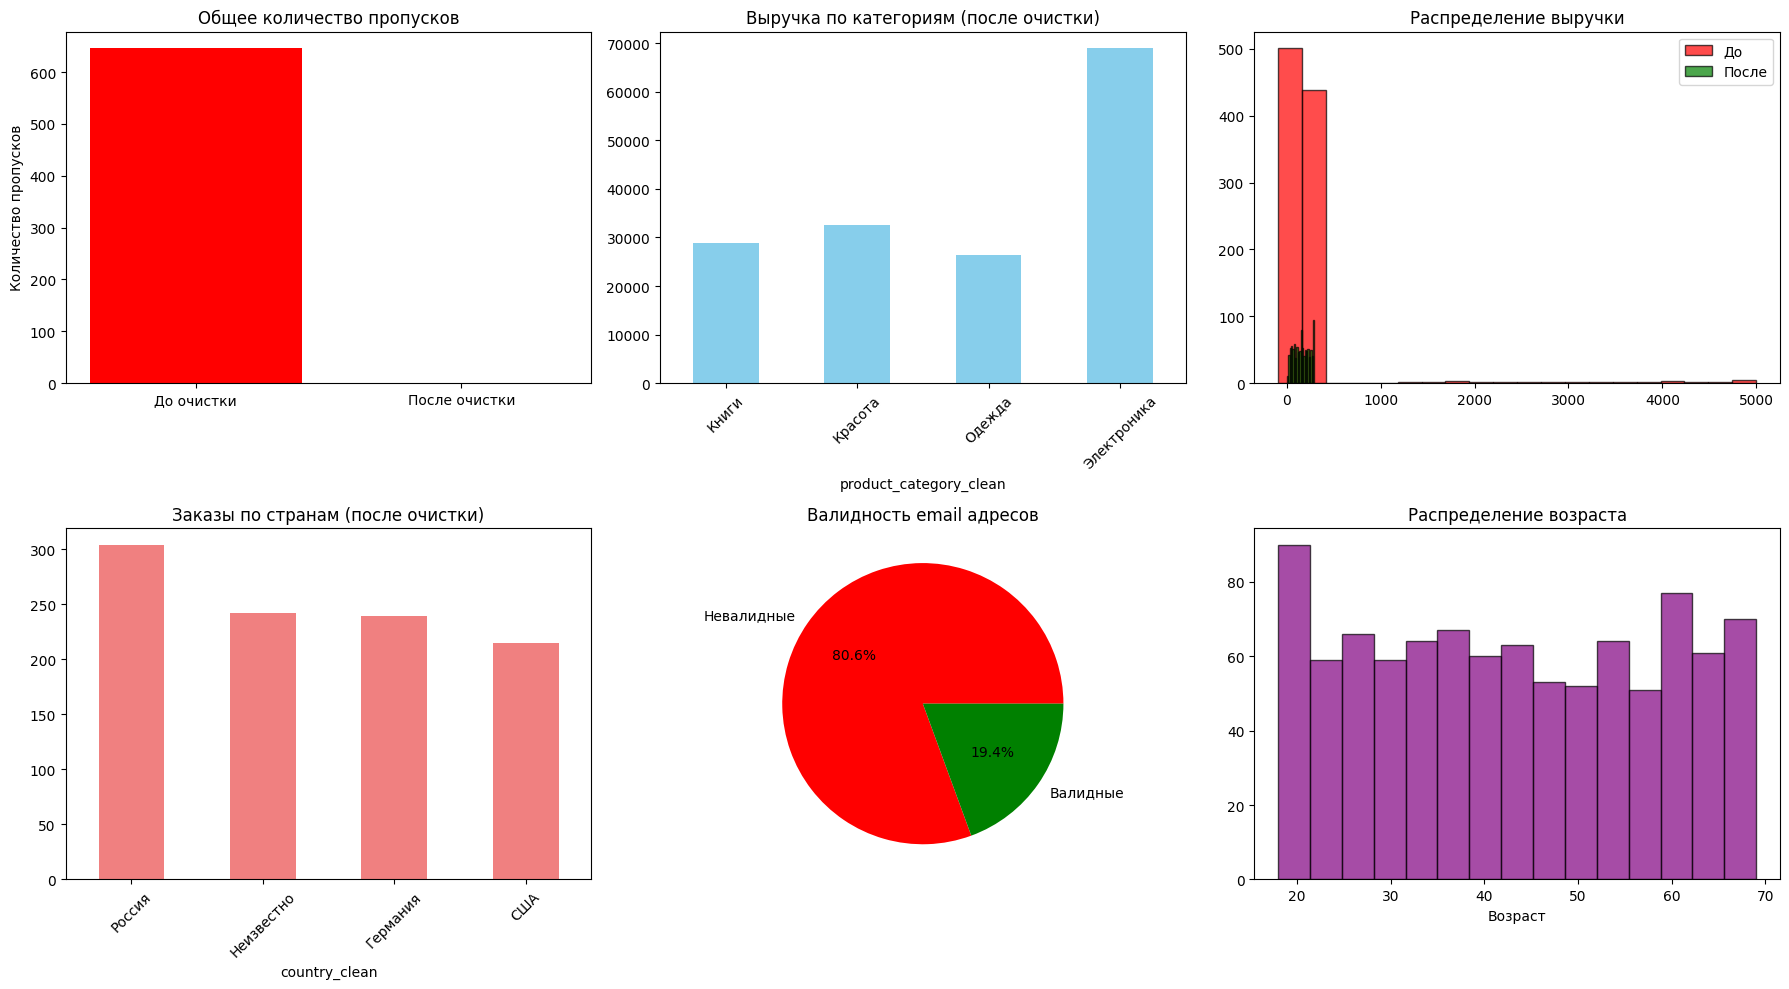

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Пропуски до и после
missing_before = df.isnull().sum()
missing_after = df_clean[['revenue_clean', 'product_category_clean', 'country_clean', 'order_date_clean']].isnull().sum()

axes[0, 0].bar(['До очистки', 'После очистки'], 
               [missing_before.sum(), missing_after.sum()], 
               color=['red', 'green'])
axes[0, 0].set_title('Общее количество пропусков')
axes[0, 0].set_ylabel('Количество пропусков')

# 2. Выручка по категориям
category_revenue['Выручка'].plot(kind='bar', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Выручка по категориям (после очистки)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Распределение выручки до и после
axes[0, 2].hist(df['revenue'].dropna(), bins=20, alpha=0.7, label='До', color='red', edgecolor='black')
axes[0, 2].hist(df_clean['revenue_clean'], bins=20, alpha=0.7, label='После', color='green', edgecolor='black')
axes[0, 2].set_title('Распределение выручки')
axes[0, 2].legend()

# 4. Количество заказов по странам
df_clean['country_clean'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Заказы по странам (после очистки)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Валидность email
email_stats = [len(df_clean) - valid_emails, valid_emails]
axes[1, 1].pie(email_stats, labels=['Невалидные', 'Валидные'], autopct='%1.1f%%', colors=['red', 'green'])
axes[1, 1].set_title('Валидность email адресов')

# 6. Распределение возраста
axes[1, 2].hist(df_clean['age_clean'], bins=15, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Распределение возраста')
axes[1, 2].set_xlabel('Возраст')

plt.tight_layout()
plt.savefig('data_cleaning_results.png', dpi=300, bbox_inches='tight')
plt.show()
